# Transverse-Field Ising Phase Transition Filtering

This notebook uses a small transverse-field Ising chain as a concrete condensed-matter model. The exact spectrum shows the finite-size precursor of the quantum phase transition near transverse field $h/J = 1$.

A low-energy QSVT-style polynomial projector is then applied near one field value to isolate the ground-state sector from the rest of the spectrum.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a finite transverse-field Ising chain scanned across field strengths.

**QSVT implementation.** It uses a low-energy projector polynomial near a selected field value. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact finite-size spectra and magnetization diagnostics validate the filter. For larger spin systems, QSVT low-energy filters are relevant to phase diagnostics and state preparation when Hamiltonian block encodings are available.


## Variable definitions

- `n_spins`: number of spins in the finite Ising chain.
- `fields`: transverse-field values in the parameter sweep.
- `magnetization_op`: average longitudinal magnetization operator.
- `magnetization_squared_op`: squared magnetization observable.
- `gaps`: finite-size spectral gaps across the sweep.
- `magnetizations`: ground-state magnetization-squared values across the sweep.
- `H`, `evals`, `evecs`, `ground`: Hamiltonian, spectrum, eigenvectors, and ground state at a sweep point.
- `min_gap_idx`, `max_magnetization_idx`: indices of diagnostic extrema.
- `target_field`: field value selected for projector filtering.
- `cutoff`: energy threshold for the ground-state projector.
- `scaled`: rescaling metadata for the selected Hamiltonian.
- `scaled_values_by_energy`, `scaled_evals`, `scaled_gap`: scaled spectral diagnostics.
- `coeffs`: low-energy projector polynomial coefficients.
- `projector_poly`: polynomial ground-state projector.
- `projector_eigenweights`: polynomial weights on exact eigenvalues.
- `exact_ground_projector`: exact ground-state projector.
- `projector_error`: projector approximation error.
- `fig`, `axes`, `spin_x`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.hamiltonians import ising_hamiltonian, pauli_string_matrix
from qsvt.matrix_functions import design_low_energy_projector_polynomial
from qsvt.polynomials import eval_polynomial
from qsvt.rescaling import rescale_hermitian_about_cutoff
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_spins = 5
fields = np.linspace(0.2, 1.8, 25)

magnetization_op = (
    sum(
        pauli_string_matrix(
            "".join("Z" if site == i else "I" for site in range(n_spins))
        ).real
        for i in range(n_spins)
    )
    / n_spins
)
magnetization_squared_op = magnetization_op @ magnetization_op

gaps = []
magnetizations = []
for h in fields:
    H = ising_hamiltonian(n_spins, coupling=1.0, transverse_field=h, periodic=False)
    evals, evecs = eigh_hermitian(H)
    ground = evecs[:, 0]
    gaps.append(evals[2] - evals[0])
    magnetizations.append(np.vdot(ground, magnetization_squared_op @ ground).real)

gaps = np.asarray(gaps)
magnetizations = np.asarray(magnetizations)

min_gap_idx = int(np.argmin(gaps))
max_magnetization_idx = int(np.argmax(magnetizations))

print("Ising sweep diagnostics")
print("-----------------------")
print(f"Minimum gap field [coupling ratio h/J]       : {fields[min_gap_idx]:.3g}")
print(f"Minimum gap [coupling units]             : {gaps[min_gap_idx]:.4g}")
print(
    f"Maximum magnetization field [coupling ratio h/J] : {fields[max_magnetization_idx]:.3g}"
)
print(
    f"Maximum magnetization [magnetization squared]       : {magnetizations[max_magnetization_idx]:.4g}"
)

Ising sweep diagnostics
-----------------------
Minimum gap field [coupling ratio h/J]       : 0.6
Minimum gap [coupling units]             : 1.394
Maximum magnetization field [coupling ratio h/J] : 0.2
Maximum magnetization [magnetization squared]       : 0.9818


## Spin-chain schematic

The transverse-field Ising chain trades ferromagnetic Z coupling against a transverse X field. The finite chain shows the gap narrowing near the critical region.


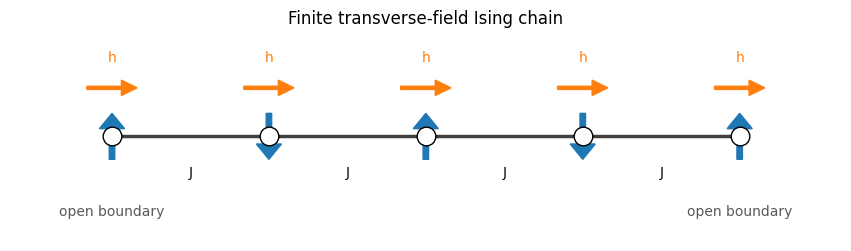

In [3]:
fig, ax = plt.subplots(figsize=(8.4, 2.4), constrained_layout=True)

spin_x = np.arange(n_spins)
for site in range(n_spins - 1):
    ax.plot([site, site + 1], [0, 0], color="0.25", linewidth=2.5)
    ax.text(site + 0.5, -0.28, "J", ha="center", va="center")

for site in spin_x:
    direction = 1 if site % 2 == 0 else -1
    ax.arrow(
        site,
        -0.18 * direction,
        0,
        0.36 * direction,
        width=0.035,
        head_width=0.16,
        head_length=0.12,
        color="tab:blue",
        length_includes_head=True,
    )
    ax.scatter(site, 0, s=180, color="white", edgecolor="black", zorder=3)
    ax.arrow(
        site - 0.16,
        0.38,
        0.32,
        0,
        width=0.025,
        head_width=0.12,
        head_length=0.10,
        color="tab:orange",
        length_includes_head=True,
    )
    ax.text(site, 0.62, "h", ha="center", va="center", color="tab:orange")

ax.text(0, -0.62, "open boundary", ha="center", color="0.35")
ax.text(n_spins - 1, -0.62, "open boundary", ha="center", color="0.35")
ax.set_title("Finite transverse-field Ising chain")
ax.set_xlim(-0.65, n_spins - 0.35)
ax.set_ylim(-0.82, 0.82)
ax.axis("off")
plt.show()

## Low-energy polynomial projector

At one field value, choose a cutoff halfway between the ground and first excited levels. After shifting around that cutoff, eigenvalues below the cutoff map to positive scaled values, so a projector polynomial approximates the low-energy spectral projector.

In [4]:
target_field = 1.2
H = ising_hamiltonian(
    n_spins, coupling=1.0, transverse_field=target_field, periodic=False
)
evals, evecs = eigh_hermitian(H)
cutoff = 0.5 * (evals[0] + evals[1])
scaled = rescale_hermitian_about_cutoff(H, cutoff, low_energy_positive=True)
scaled_values_by_energy = (evals - scaled.offset) / scaled.scale
scaled_evals = np.linalg.eigvalsh(scaled.matrix)
scaled_gap = min(abs(scaled_values_by_energy[scaled_values_by_energy > 0]))

coeffs = design_low_energy_projector_polynomial(gap=0.55 * scaled_gap, degree=31)
projector_poly = apply_polynomial_to_hermitian(scaled.matrix, coeffs)
projector_eigenweights = eval_polynomial(coeffs, scaled_values_by_energy)

exact_ground_projector = np.outer(evecs[:, 0], evecs[:, 0].conj())
projector_error = np.linalg.norm(projector_poly - exact_ground_projector)
print("Projector eigenweights [probability]:", projector_eigenweights[:5])
print("Projector error:", projector_error)

Projector eigenweights [probability]: [0.7761 0.2239 0.0087 0.1109 0.1143]
Projector error: 0.5286773050862152


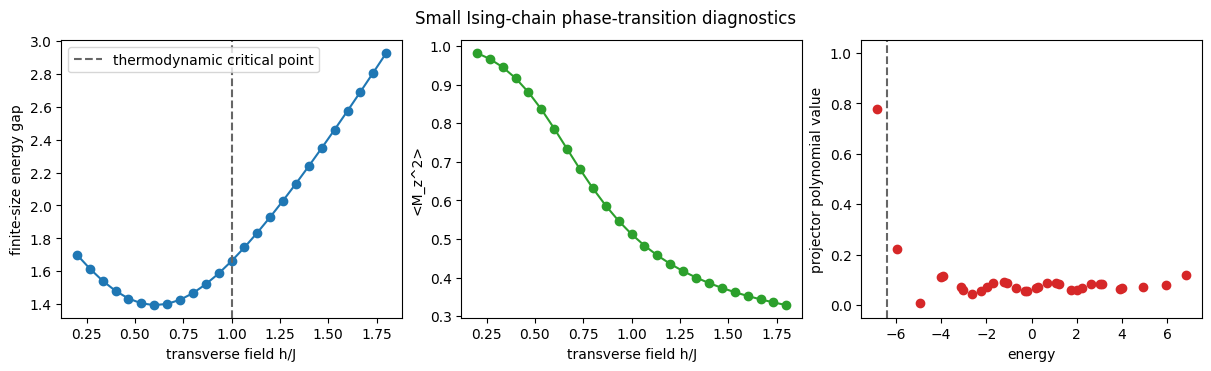

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

axes[0].plot(fields, gaps, "o-")
axes[0].axvline(1.0, color="0.4", linestyle="--", label="thermodynamic critical point")
axes[0].set_xlabel("transverse field h/J")
axes[0].set_ylabel("finite-size energy gap")
axes[0].legend()

axes[1].plot(fields, magnetizations, "o-", color="tab:green")
axes[1].set_xlabel("transverse field h/J")
axes[1].set_ylabel("<M_z^2>")

axes[2].scatter(evals, projector_eigenweights, color="tab:red")
axes[2].axvline(cutoff, color="0.4", linestyle="--")
axes[2].set_xlabel("energy")
axes[2].set_ylabel("projector polynomial value")
axes[2].set_ylim(-0.05, 1.05)

fig.suptitle("Small Ising-chain phase-transition diagnostics")
plt.show()

In [6]:
assert gaps[0] > gaps[np.argmin(np.abs(fields - 1.0))]
assert magnetizations[0] > magnetizations[-1]
assert projector_eigenweights[0] > projector_eigenweights[1]
assert projector_eigenweights[0] > 0.5
assert projector_error < 1.1

print(f"minimum_doublet_gap_field [coupling ratio h/J]: {fields[np.argmin(gaps)]:.3f}")
print(
    f"magnetization_drop [magnetization squared]: {magnetizations[0] - magnetizations[-1]:.3f}"
)
print(f"projector_error: {projector_error:.3f}")
print("validation: passed")

minimum_doublet_gap_field [coupling ratio h/J]: 0.600
magnetization_drop [magnetization squared]: 0.653
projector_error: 0.529
validation: passed
